# Exploratory Data Analytics (EDA)

**Student:** Debojyoti Mahapatra  
**Assignment:** Perform Exploratory Data Analysis for all five Kaggle datasets recommended by Erkki Räsänen.

This completed notebook keeps the original Penguin analysis and continues with Titanic, Avocado Prices, 80 Cereals, and Red Wine Quality.

## How to use this notebook

Run the cells from top to bottom. In Google Colab, select **Runtime → Run all**. A code cell creates variables that later cells use, so running the notebook out of order can cause a `NameError`.

Each dataset follows the same learning pattern:

1. load and preview the CSV;
2. inspect rows, columns, data types, missing values, and duplicates;
3. calculate descriptive statistics;
4. make charts appropriate to the question;
5. inspect correlations and possible outliers;
6. write an **observation**, **interpretation**, and **limitation**.

A correlation describes variables moving together. It does **not** by itself prove that one variable causes the other.


## 1. Palmer Archipelago Penguins

This is the dataset you had already started. Your original loading, inspection, descriptive-statistics, and chart cells are retained below, with small wording and Markdown corrections.


In [1]:
import pandas as pd
from pathlib import Path

# When the repository is cloned, use the local CSV. In Colab, use the raw GitHub URL.
local_file = Path("peguins/penguins_size.csv")
url = (
    "https://raw.githubusercontent.com/"
    "dmahapatra/metropolia-deb-applied-analytics/"
    "main/peguins/penguins_size.csv"
)

data_source = local_file if local_file.exists() else url
penguins = pd.read_csv(data_source, na_values=["NA", "."])

penguins.head()

Out[1]: 
  species     island  culmen_length_mm  ...  flipper_length_mm  body_mass_g     sex
0  Adelie  Torgersen              39.1  ...              181.0       3750.0    MALE
1  Adelie  Torgersen              39.5  ...              186.0       3800.0  FEMALE
2  Adelie  Torgersen              40.3  ...              195.0       3250.0  FEMALE
3  Adelie  Torgersen               NaN  ...                NaN          NaN     NaN
4  Adelie  Torgersen              36.7  ...              193.0       3450.0  FEMALE

[5 rows x 7 columns]


### 1.1 Basic dataset information and dimensions

In [2]:
# Check the shape of the dataset (rows, columns)
print(f"Dataset Shape: {penguins.shape}\n")

# Display detailed column information
penguins.info()

Dataset Shape: (344, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   culmen_length_mm   342 non-null    float64
 3   culmen_depth_mm    342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
dtypes: float64(4), object(3)
memory usage: 18.9+ KB


### 1.2 Missing-value analysis

In [3]:
# Calculate and display the number of missing values per column
missing_values = penguins.isnull().sum()
display(missing_values.to_frame(name='Missing Values count'))

,Missing Values count
species,0
island,0
culmen_length_mm,2
culmen_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


### 1.3 Descriptive statistics
Let's examine summary statistics for numeric columns and frequency counts for categorical columns.

In [4]:
# Summary statistics for numerical columns
display(penguins.describe())

# Frequency distribution for categorical features
print("Value counts for species:")
display(penguins['species'].value_counts())

print("\nValue counts for island:")
display(penguins['island'].value_counts())

print("\nValue counts for sex:")
display(penguins['sex'].value_counts(dropna=False))

Value counts for species:

Value counts for island:

Value counts for sex:


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
count,342.000000,342.000000,342.000000,342.000000
mean,43.921930,17.151170,200.915205,4201.754386
std,5.459584,1.974793,14.061714,801.954536
min,32.100000,13.100000,172.000000,2700.000000
25%,39.225000,15.600000,190.000000,3550.000000
50%,44.450000,17.300000,197.000000,4050.000000
75%,48.500000,18.700000,213.000000,4750.000000
max,59.600000,21.500000,231.000000,6300.000000


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

island
Biscoe       168
Dream        124
Torgersen     52
Name: count, dtype: int64

sex
MALE      168
FEMALE    165
NaN        11
Name: count, dtype: int64

### 1.4 Penguin charts

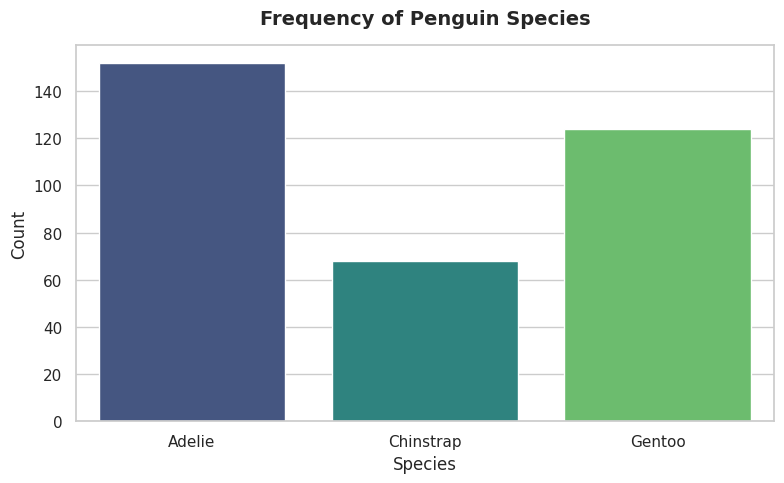

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style for the plot
sns.set_theme(style="whitegrid")

# Create a figure with a defined size
fig, ax = plt.subplots(figsize=(8, 5))

# Create a countplot for species
sns.countplot(
    data=penguins,
    x='species',
    hue='species',
    palette='viridis',
    legend=False,
    ax=ax
)

# Add details and labels to the chart
ax.set_title('Frequency of Penguin Species', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Count', fontsize=12)

# Display the plot
plt.tight_layout()
plt.show()

**Observation.** Adelie is the most common species in this dataset, followed by Gentoo. Chinstrap is the least represented species and has fewer than half as many records as Adelie.

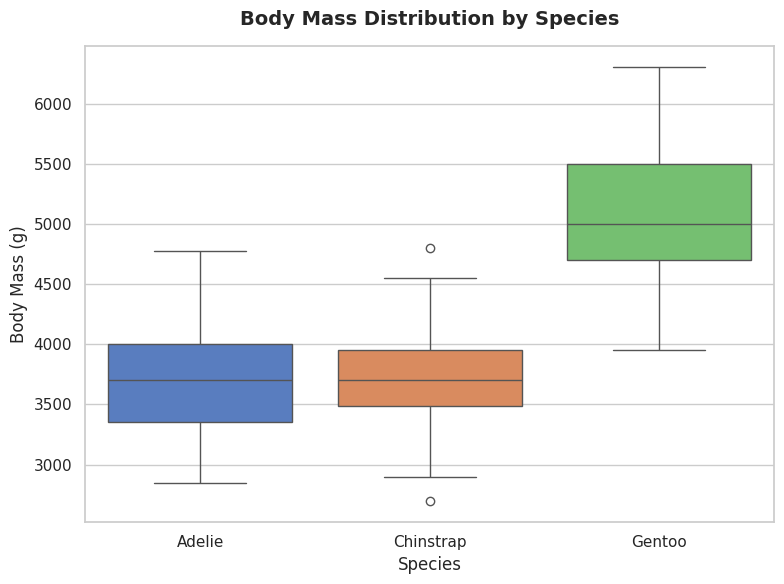

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with a defined size
fig, ax = plt.subplots(figsize=(8, 6))

# Create the box plot
sns.boxplot(
    data=penguins,
    x='species',
    y='body_mass_g',
    hue='species',
    palette='muted',
    legend=False,
    ax=ax
)

# Add title and labels
ax.set_title('Body Mass Distribution by Species', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Body Mass (g)', fontsize=12)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

**Observation.** Gentoo penguins are substantially heavier than Adelie and Chinstrap penguins. Adelie and Chinstrap have similar body-mass distributions, so body mass alone does not separate those two species well.

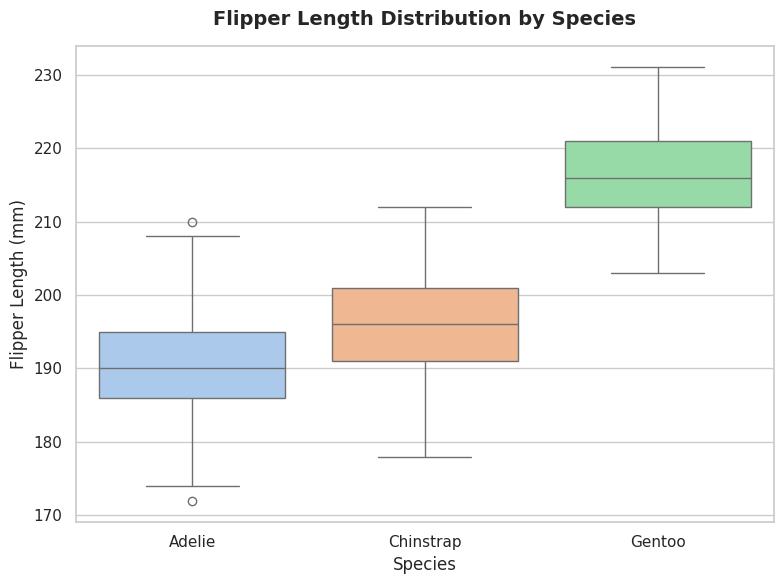

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with a defined size
fig, ax = plt.subplots(figsize=(8, 6))

# Create the box plot
sns.boxplot(
    data=penguins,
    x='species',
    y='flipper_length_mm',
    hue='species',
    palette='pastel',
    legend=False,
    ax=ax
)

# Add title and labels
ax.set_title('Flipper Length Distribution by Species', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Species', fontsize=12)
ax.set_ylabel('Flipper Length (mm)', fontsize=12)

# Adjust layout and show plot
plt.tight_layout()
plt.show()

**Observation.** Gentoo penguins have the longest flippers and the highest median flipper length. There is a clear separation between Gentoo and the other two species.

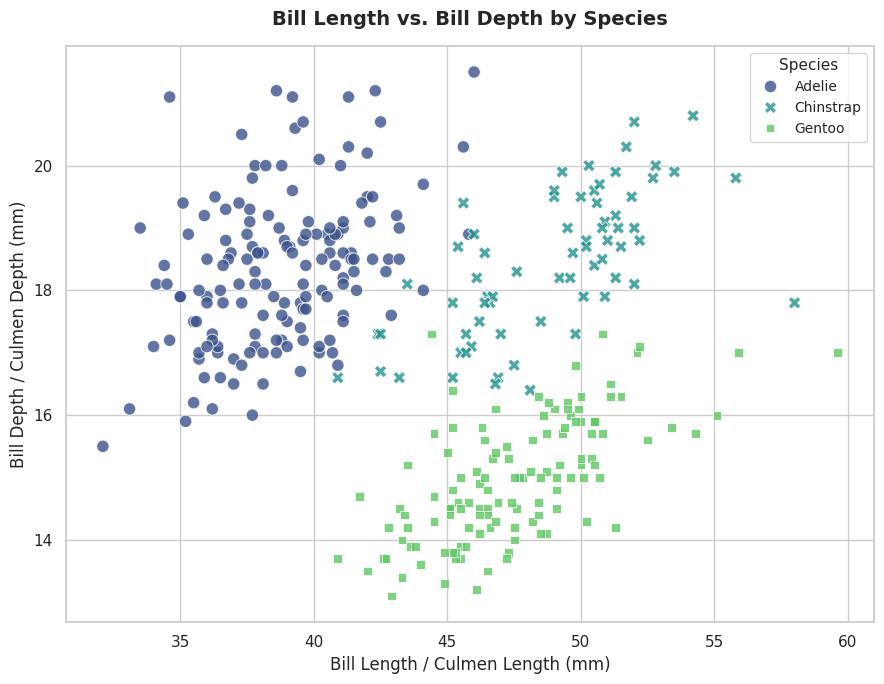

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style
sns.set_theme(style="whitegrid")

# Create a figure with a defined size
fig, ax = plt.subplots(figsize=(9, 7))

# Create the scatter plot
sns.scatterplot(
    data=penguins,
    x='culmen_length_mm',
    y='culmen_depth_mm',
    hue='species',
    style='species',
    palette='viridis',
    s=80,
    alpha=0.8,
    ax=ax
)

# Add title and labels
ax.set_title('Bill Length vs. Bill Depth by Species', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Bill Length / Culmen Length (mm)', fontsize=12)
ax.set_ylabel('Bill Depth / Culmen Depth (mm)', fontsize=12)

# Customize the legend
ax.legend(title='Species', title_fontsize='11', fontsize='10', loc='upper right')

# Adjust layout and show plot
plt.tight_layout()
plt.show()

**Observation.** Adelie penguins generally have short, deep bills. Gentoo penguins have long, shallow bills, while Chinstrap penguins have long, deep bills. The three clusters show that bill shape is useful for distinguishing species.

### 1.5 Complete the Penguin EDA: correlation, outliers, and limitations

Your charts already answer the main visual questions. The next cell adds two checks commonly expected in EDA:

- `.corr()` measures linear relationships between numeric columns from −1 to +1.
- The **IQR rule** flags values below `Q1 − 1.5 × IQR` or above `Q3 + 1.5 × IQR`. A flagged value is worth checking; it is not automatically an error.


,culmen_length_mm,culmen_depth_mm,flipper_length_mm,body_mass_g
culmen_length_mm,1.00,-0.24,0.66,0.60
culmen_depth_mm,-0.24,1.00,-0.58,-0.47
flipper_length_mm,0.66,-0.58,1.00,0.87
body_mass_g,0.60,-0.47,0.87,1.00


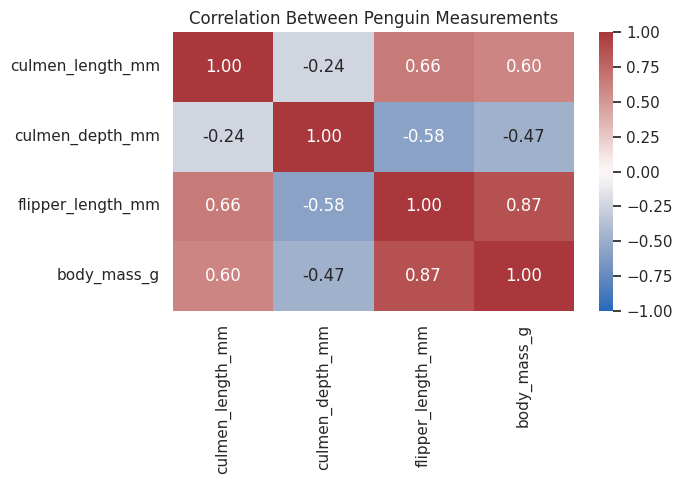

,lower_fence_g,upper_fence_g,outlier_count
species,,,
Adelie,2375.0,4975.0,0
Chinstrap,2793.8,4643.8,2
Gentoo,3500.0,6700.0,0


In [9]:
numeric_penguin_columns = [
    "culmen_length_mm",
    "culmen_depth_mm",
    "flipper_length_mm",
    "body_mass_g",
]

# Correlation matrix for the numeric measurements.
penguin_correlations = penguins[numeric_penguin_columns].corr()
display(penguin_correlations.round(2))

plt.figure(figsize=(7, 5))
sns.heatmap(
    penguin_correlations,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Between Penguin Measurements")
plt.tight_layout()
plt.show()

# Count body-mass outliers separately for each species.
outlier_rows = []
for species, group in penguins.groupby("species"):
    q1 = group["body_mass_g"].quantile(0.25)
    q3 = group["body_mass_g"].quantile(0.75)
    iqr = q3 - q1
    lower_fence = q1 - 1.5 * iqr
    upper_fence = q3 + 1.5 * iqr
    outlier_count = ((group["body_mass_g"] < lower_fence) | (group["body_mass_g"] > upper_fence)).sum()
    outlier_rows.append(
        {
            "species": species,
            "lower_fence_g": round(lower_fence, 1),
            "upper_fence_g": round(upper_fence, 1),
            "outlier_count": int(outlier_count),
        }
    )

display(pd.DataFrame(outlier_rows).set_index("species"))


**Interpretation.** Flipper length and body mass have a strong positive relationship: penguins with longer flippers tend to be heavier. However, the species clusters show that an overall correlation can partly reflect differences between groups.

**Limitation.** The cleaned compact file has 19 missing cells. The species sample sizes are unequal, and the observations come from selected islands and study years. Therefore, this dataset does not represent every penguin in the wider population.


## Shared setup for the remaining datasets

The next cell defines reusable helper functions so the same quality checks are not rewritten four times.

- `load_csv(...)` reads a local repository file when available; otherwise it reads the same file from GitHub.
- `quality_summary(...)` shows data type, missing count, missing percentage, and unique values for every column.
- `numeric_summary(...)` uses `.describe()` to calculate count, mean, standard deviation, quartiles, minimum, and maximum.
- `iqr_outliers(...)` applies the 1.5 × IQR outlier rule.


In [10]:
from pathlib import Path
from urllib.parse import quote
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 115, "axes.titleweight": "bold"})

REPOSITORY = "dmahapatra/metropolia-deb-applied-analytics"
RAW_BASE = f"https://raw.githubusercontent.com/{REPOSITORY}/main"

FILES = {
    "penguins_size": "peguins/penguins_size.csv",
    "penguins_lter": "peguins/penguins_lter.csv",
    "titanic": "titanic/train.csv",
    "avocado": "avocado/avocado.csv",
    "cereals": "Cereals/cereal.csv",
    "wine": "Wine/winequality-red.csv",
}

def load_csv(key, **kwargs):
    # Load from a cloned repository when available; otherwise use GitHub.
    relative = Path(FILES[key])
    search_roots = [Path.cwd(), Path.cwd().parent, Path("/content/metropolia-deb-applied-analytics")]
    for root in search_roots:
        candidate = root / relative
        if candidate.exists():
            return pd.read_csv(candidate, **kwargs)
    url = f"{RAW_BASE}/{quote(relative.as_posix(), safe='/')}"
    return pd.read_csv(url, **kwargs)

def dataset_overview(df, name):
    return pd.Series(
        {
            "rows": len(df),
            "columns": df.shape[1],
            "duplicate rows": int(df.duplicated().sum()),
            "missing cells": int(df.isna().sum().sum()),
        },
        name=name,
    ).to_frame("value")

def quality_summary(df):
    return pd.DataFrame(
        {
            "dtype": df.dtypes.astype(str),
            "missing": df.isna().sum(),
            "missing_%": (100 * df.isna().mean()).round(1),
            "unique": df.nunique(dropna=True),
        }
    )

def numeric_summary(df):
    numeric = df.select_dtypes(include=np.number)
    return numeric.describe().T.round(2) if not numeric.empty else pd.DataFrame()

def show_basic_eda(df, name):
    display(dataset_overview(df, name))
    display(df.head())
    display(quality_summary(df))
    display(numeric_summary(df))

def iqr_outliers(series):
    # Return Tukey 1.5 x IQR fences and outlier count for one numeric series.
    x = pd.to_numeric(series, errors="coerce").dropna()
    q1, q3 = x.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    count = int(((x < lower) | (x > upper)).sum())
    return {"Q1": q1, "Q3": q3, "lower fence": lower, "upper fence": upper, "outliers": count}

def grouped_iqr_outliers(df, value, group):
    rows = []
    for label, part in df.groupby(group, observed=True):
        rows.append({group: label, **iqr_outliers(part[value])})
    return pd.DataFrame(rows).set_index(group).round(2)

def iqr_table(df, columns):
    rows = [{"variable": col, **iqr_outliers(df[col])} for col in columns]
    return pd.DataFrame(rows).set_index("variable").sort_values("outliers", ascending=False).round(2)


## 2. Titanic

The target variable is `Survived`. EDA focuses on missing values and differences by sex, passenger class, age, and fare. These are observational associations from one disaster, not causal effects.


### Commands used in the Titanic section

- `.map({0: ..., 1: ...})` changes numeric codes into readable labels.
- `pd.cut(...)` places continuous ages into age bands.
- `.groupby(...).mean()` calculates a rate because the mean of a 0/1 column is the proportion of 1s.
- `.pivot_table(...)` creates a small matrix of survival rates for the heatmap.

**Small example:** if `Survived = [1, 0, 1, 0]`, its mean is `0.5`, meaning 50% survived.


In [11]:
titanic_raw = load_csv("titanic")
titanic = titanic_raw.copy()
titanic["Survival"] = titanic["Survived"].map({0: "Did not survive", 1: "Survived"})
titanic["Pclass_label"] = pd.Categorical(
    titanic["Pclass"].map({1: "1st", 2: "2nd", 3: "3rd"}),
    categories=["1st", "2nd", "3rd"],
    ordered=True,
)
titanic["Age_band"] = pd.cut(
    titanic["Age"],
    bins=[0, 12, 18, 35, 60, np.inf],
    labels=["Child", "Teen", "19–35", "36–60", "61+"],
    include_lowest=True,
)

show_basic_eda(titanic_raw, "Titanic training data")

survival_summary = pd.DataFrame(
    {
        "count": titanic.groupby("Sex")["Survived"].size(),
        "survival_rate_%": 100 * titanic.groupby("Sex")["Survived"].mean(),
    }
).round(1)
display(survival_summary)
display((100 * titanic.groupby("Pclass")["Survived"].mean()).round(1).to_frame("survival_rate_%"))


,value
rows,891
columns,12
duplicate rows,0
missing cells,866


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000,1,0,A/5 21171,7.250,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000,1,0,PC 17599,71.283,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000,0,0,STON/O2. 3101282,7.925,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000,1,0,113803,53.100,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.000,0,0,373450,8.050,NaN,S


,dtype,missing,missing_%,unique
PassengerId,int64,0,0.000,891
Survived,int64,0,0.000,2
Pclass,int64,0,0.000,3
Name,object,0,0.000,891
Sex,object,0,0.000,2
Age,float64,177,19.900,88
SibSp,int64,0,0.000,7
Parch,int64,0,0.000,7
Ticket,object,0,0.000,681
Fare,float64,0,0.000,248


,count,mean,std,min,25%,50%,75%,max
PassengerId,891.000,446.000,257.350,1.000,223.500,446.000,668.500,891.000
Survived,891.000,0.380,0.490,0.000,0.000,0.000,1.000,1.000
Pclass,891.000,2.310,0.840,1.000,2.000,3.000,3.000,3.000
Age,714.000,29.700,14.530,0.420,20.120,28.000,38.000,80.000
SibSp,891.000,0.520,1.100,0.000,0.000,0.000,1.000,8.000
Parch,891.000,0.380,0.810,0.000,0.000,0.000,0.000,6.000
Fare,891.000,32.200,49.690,0.000,7.910,14.450,31.000,512.330


,count,survival_rate_%
Sex,,
female,314,74.200
male,577,18.900


,survival_rate_%
Pclass,
1,63.000
2,47.300
3,24.200


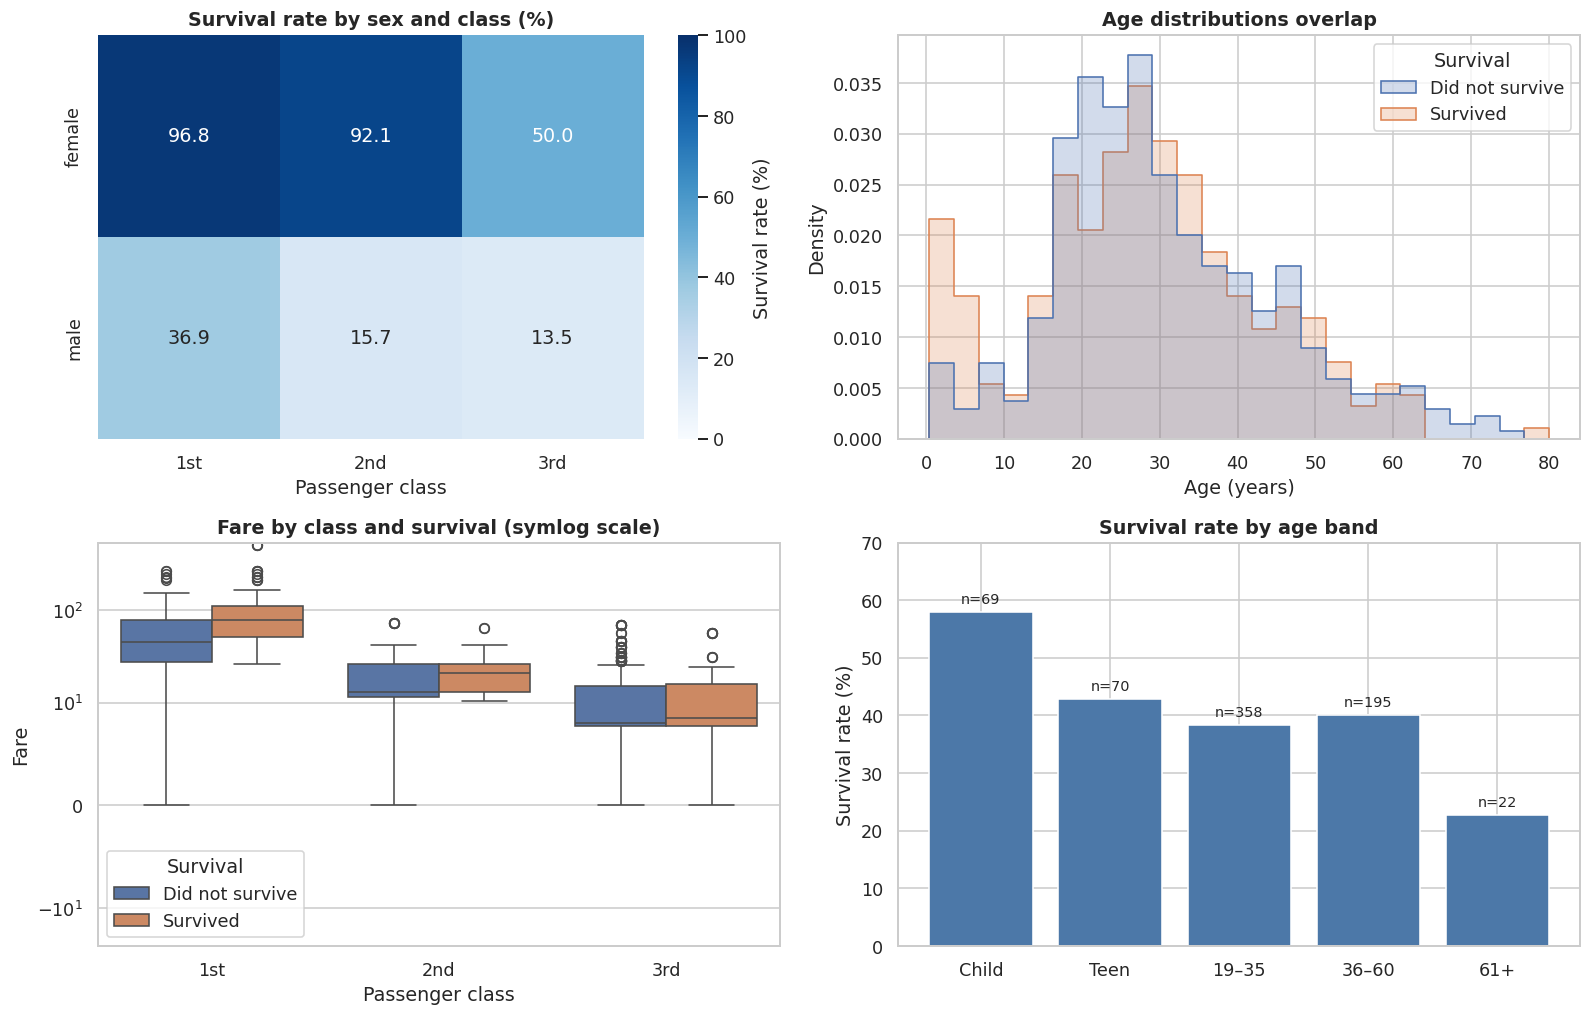

,Q1,Q3,lower fence,upper fence,outliers
Pclass_label,,,,,
1st,30.920,93.500,-62.940,187.360,20
2nd,13.000,26.000,-6.500,45.500,7
3rd,7.750,15.500,-3.880,27.120,52


In [12]:
rates = titanic.pivot_table(index="Sex", columns="Pclass_label", values="Survived", aggfunc="mean", observed=False)
age_rates = titanic.groupby("Age_band", observed=False)["Survived"].agg(["mean", "count"])

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.heatmap(100 * rates, annot=True, fmt=".1f", cmap="Blues", vmin=0, vmax=100, cbar_kws={"label": "Survival rate (%)"}, ax=axes[0, 0])
axes[0, 0].set_title("Survival rate by sex and class (%)")
axes[0, 0].set_xlabel("Passenger class")
axes[0, 0].set_ylabel("")

sns.histplot(data=titanic, x="Age", hue="Survival", bins=25, element="step", stat="density", common_norm=False, ax=axes[0, 1])
axes[0, 1].set_title("Age distributions overlap")
axes[0, 1].set_xlabel("Age (years)")
axes[0, 1].set_ylabel("Density")

sns.boxplot(data=titanic, x="Pclass_label", y="Fare", hue="Survival", ax=axes[1, 0])
axes[1, 0].set_yscale("symlog", linthresh=10)
axes[1, 0].set_title("Fare by class and survival (symlog scale)")
axes[1, 0].set_xlabel("Passenger class")
axes[1, 0].set_ylabel("Fare")

axes[1, 1].bar(age_rates.index.astype(str), 100 * age_rates["mean"], color="#4c78a8")
for i, row in enumerate(age_rates.itertuples()):
    axes[1, 1].text(i, 100 * row.mean + 1.5, f"n={int(row.count)}", ha="center", fontsize=9)
axes[1, 1].set_ylim(0, max(70, 100 * age_rates["mean"].max() + 12))
axes[1, 1].set_title("Survival rate by age band")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("Survival rate (%)")

plt.tight_layout()
plt.show()

display(grouped_iqr_outliers(titanic, "Fare", "Pclass_label"))


**Observation.** Overall, 38.4% of the 891 passengers survived. The survival rate is 74.2% for women and 18.9% for men. It falls from 63.0% in first class to 24.2% in third class. The median fare is 26.00 for survivors and 10.50 for non-survivors.

**Interpretation.** Sex and passenger class separate survival outcomes much more strongly than age alone. Fare is related to class and travel arrangements, so its association with survival should not be read as a direct causal effect.

**Limitation.** Age is missing for 177 passengers, cabin for 687, and embarkation port for 2. Missing age values affect the age plots. The data describe one historical event and cannot isolate causal mechanisms.


## 3. Avocado Prices

This dataset is a time series of weekly region–type records. The first unnamed column is an exported row index and is removed. National (`TotalUS`) rows are used for volume plots so national, regional, and city totals are not added together and double-counted.


### Commands used in the Avocado section

- `pd.to_datetime(...)` converts text dates into real date values that Python can sort and group.
- `.dt.to_period("M")` groups weekly dates into months.
- `.sort_values("Date")` ensures a time-series line is drawn chronologically.
- A logarithmic axis helps display very different sales volumes without hiding the smaller values.

**Small example:** the dates `2017-01-01` and `2017-01-29` both belong to the month `2017-01`.


In [13]:
avocado_raw = load_csv("avocado")
avocado = avocado_raw.drop(columns=["Unnamed: 0"], errors="ignore").copy()
avocado["Date"] = pd.to_datetime(avocado["Date"])
avocado["month"] = avocado["Date"].dt.to_period("M").dt.to_timestamp()
avocado = avocado.sort_values("Date")

show_basic_eda(avocado.drop(columns="month"), "Avocado prices (cleaned)")
print(f"Date range: {avocado['Date'].min().date()} to {avocado['Date'].max().date()}")
print(f"Region labels: {avocado['region'].nunique()}")

yearly_price = avocado.groupby(["year", "type"])["AveragePrice"].agg(["count", "mean", "median", "std"]).round(3)
display(yearly_price)


Date range: 2015-01-04 to 2018-03-25
Region labels: 54


,value
rows,18249
columns,13
duplicate rows,0
missing cells,0


,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
11569,2015-01-04,1.750,"27,365.890","9,307.340","3,844.810",615.280,"13,598.460","13,061.100",537.360,0.000,organic,2015,Southeast
9593,2015-01-04,1.490,"17,723.170","1,189.350","15,628.270",0.000,905.550,905.550,0.000,0.000,organic,2015,Chicago
10009,2015-01-04,1.680,"2,896.720",161.680,206.960,0.000,"2,528.080","2,528.080",0.000,0.000,organic,2015,HarrisburgScranton
1819,2015-01-04,1.520,"54,956.800","3,013.040","35,456.880","1,561.700","14,925.180","11,264.800","3,660.380",0.000,conventional,2015,Pittsburgh
9333,2015-01-04,1.640,"1,505.120",1.270,"1,129.500",0.000,374.350,186.670,187.680,0.000,organic,2015,Boise


,dtype,missing,missing_%,unique
Date,datetime64[ns],0,0.000,169
AveragePrice,float64,0,0.000,259
Total Volume,float64,0,0.000,18237
4046,float64,0,0.000,17702
4225,float64,0,0.000,18103
4770,float64,0,0.000,12071
Total Bags,float64,0,0.000,18097
Small Bags,float64,0,0.000,17321
Large Bags,float64,0,0.000,15082
XLarge Bags,float64,0,0.000,5588


,count,mean,std,min,25%,50%,75%,max
AveragePrice,"18,249.000",1.410,0.400,0.440,1.100,1.370,1.660,3.250
Total Volume,"18,249.000","850,644.010","3,453,545.360",84.560,"10,838.580","107,376.760","432,962.290","62,505,646.520"
4046,"18,249.000","293,008.420","1,264,989.080",0.000,854.070,"8,645.300","111,020.200","22,743,616.170"
4225,"18,249.000","295,154.570","1,204,120.400",0.000,"3,008.780","29,061.020","150,206.860","20,470,572.610"
4770,"18,249.000","22,839.740","107,464.070",0.000,0.000,184.990,"6,243.420","2,546,439.110"
Total Bags,"18,249.000","239,639.200","986,242.400",0.000,"5,088.640","39,743.830","110,783.370","19,373,134.370"
Small Bags,"18,249.000","182,194.690","746,178.510",0.000,"2,849.420","26,362.820","83,337.670","13,384,586.800"
Large Bags,"18,249.000","54,338.090","243,965.960",0.000,127.470,"2,647.710","22,029.250","5,719,096.610"
XLarge Bags,"18,249.000","3,106.430","17,692.890",0.000,0.000,0.000,132.500,"551,693.650"
year,"18,249.000","2,016.150",0.940,"2,015.000","2,015.000","2,016.000","2,017.000","2,018.000"


count  mean  median   std
year type                                   
2015 conventional   2808 1.078   1.080 0.170
     organic        2807 1.673   1.670 0.276
2016 conventional   2808 1.106   1.080 0.254
     organic        2808 1.572   1.530 0.370
2017 conventional   2862 1.295   1.300 0.302
     organic        2860 1.736   1.720 0.432
2018 conventional    648 1.128   1.140 0.205
     organic         648 1.567   1.550 0.220

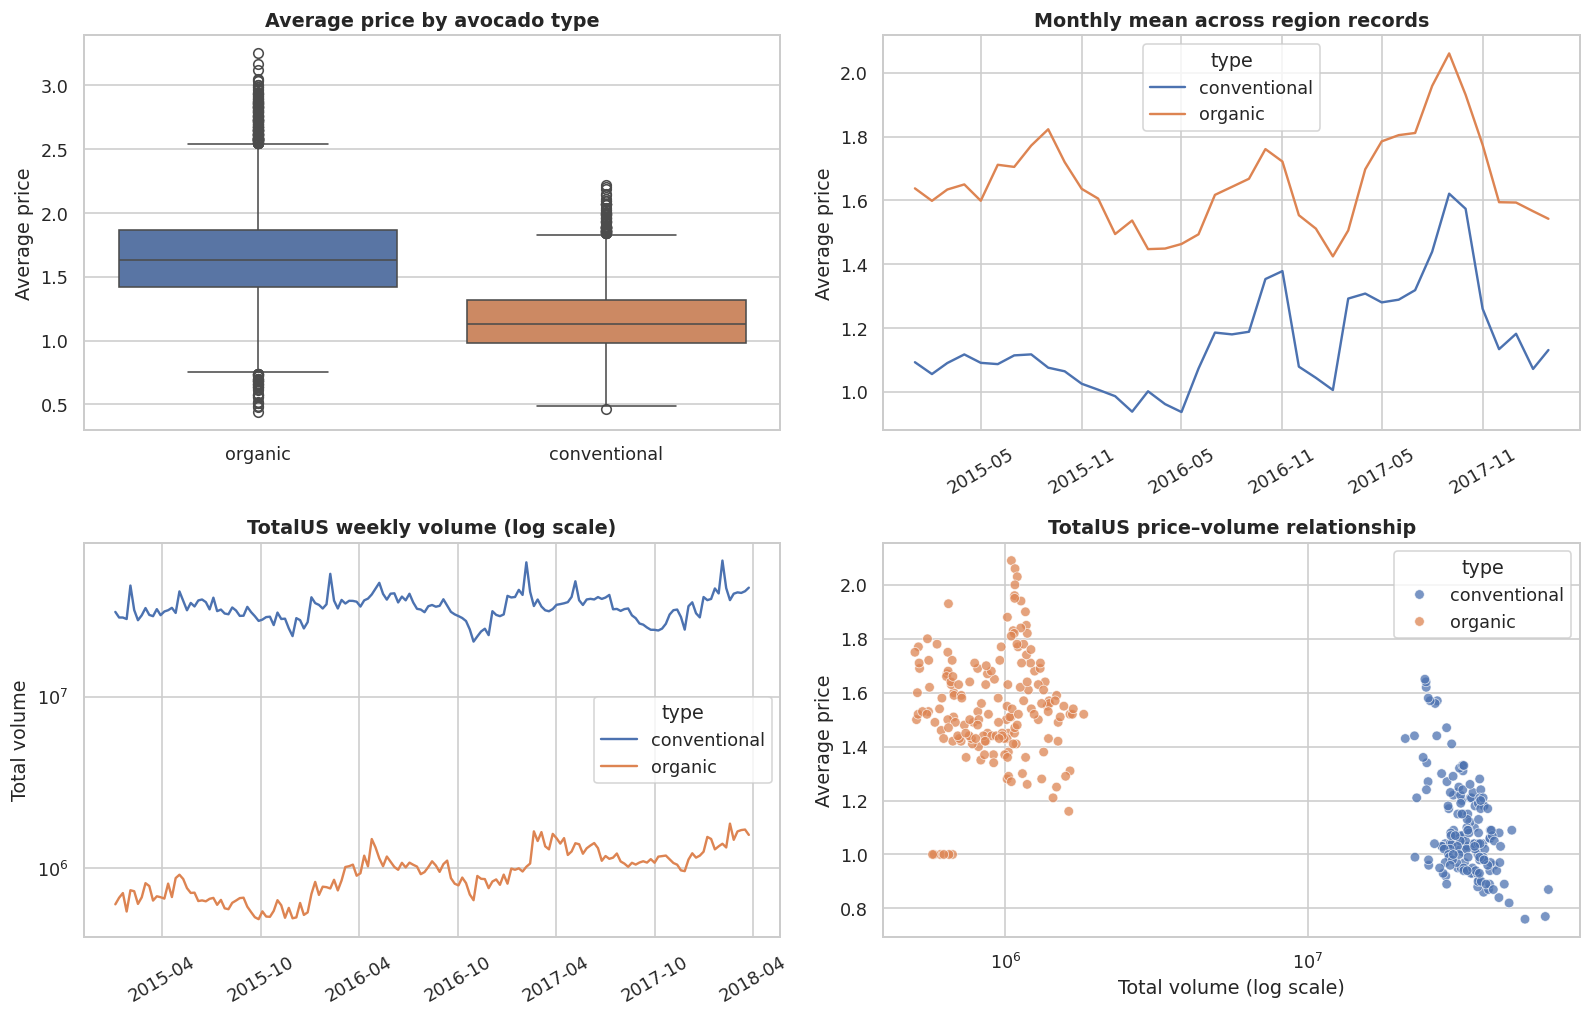

,price-volume correlation (TotalUS)
conventional,-0.510
organic,0.024


,Q1,Q3,lower fence,upper fence,outliers
type,,,,,
conventional,0.980,1.320,0.470,1.830,90
organic,1.420,1.870,0.740,2.550,225


In [14]:
monthly_price = avocado.groupby(["month", "type"], as_index=False)["AveragePrice"].mean()
total_us = avocado.loc[avocado["region"].eq("TotalUS")].copy()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.boxplot(data=avocado, x="type", y="AveragePrice", hue="type", legend=False, ax=axes[0, 0])
axes[0, 0].set_title("Average price by avocado type")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("Average price")

sns.lineplot(data=monthly_price, x="month", y="AveragePrice", hue="type", ax=axes[0, 1])
axes[0, 1].set_title("Monthly mean across region records")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("Average price")
axes[0, 1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[0, 1].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[0, 1].tick_params(axis="x", rotation=30)

sns.lineplot(data=total_us, x="Date", y="Total Volume", hue="type", ax=axes[1, 0])
axes[1, 0].set_yscale("log")
axes[1, 0].set_title("TotalUS weekly volume (log scale)")
axes[1, 0].set_xlabel("")
axes[1, 0].set_ylabel("Total volume")
axes[1, 0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1, 0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
axes[1, 0].tick_params(axis="x", rotation=30)

sns.scatterplot(data=total_us, x="Total Volume", y="AveragePrice", hue="type", alpha=0.75, ax=axes[1, 1])
axes[1, 1].set_xscale("log")
axes[1, 1].set_title("TotalUS price–volume relationship")
axes[1, 1].set_xlabel("Total volume (log scale)")
axes[1, 1].set_ylabel("Average price")

plt.tight_layout()
plt.show()

price_volume_corr = pd.Series(
    {
        avocado_type: group["AveragePrice"].corr(group["Total Volume"])
        for avocado_type, group in total_us.groupby("type")
    },
    name="price-volume correlation (TotalUS)",
)
display(price_volume_corr.round(3).to_frame())
display(grouped_iqr_outliers(avocado, "AveragePrice", "type"))


**Observation.** The cleaned data contain 18,249 weekly region–type records from 2015-01-04 through 2018-03-25 and 54 region labels. Organic avocados have a median average price of 1.63, compared with 1.13 for conventional avocados. Both types vary over time, with especially high monthly mean prices in September 2017.

**Interpretation.** The organic price premium persists across years, while the time plot shows that market conditions also change. The national volume chart avoids double-counting caused by overlapping geographic totals. The price–volume scatter describes association only; both variables may respond to season, supply, and demand.

**Limitation.** The monthly price lines are unweighted means across region records, so small and large markets have equal influence. The file ends in March 2018, so 2018 is only a partial year and should not be compared as a complete annual period.


## 4. 80 Cereals

The file title says “80 Cereals,” but the CSV contains 77 products. The source uses `-1` to mark unavailable carbohydrate, sugar, or potassium values; these sentinel codes are converted to missing values before calculation.


### Commands used in the Cereals section

- `.replace(-1, np.nan)` changes the source's missing-value code into a real missing value.
- `.nlargest(10, "rating")` returns the ten highest-rated cereals.
- `.corr()` measures the direction and strength of linear relationships.

**Small example:** a correlation near `-1` means that as one variable increases, the other usually decreases.


In [15]:
cereals_raw = load_csv("cereals")
cereals = cereals_raw.copy()
sentinel_columns = ["carbo", "sugars", "potass"]
sentinel_counts = (cereals[sentinel_columns] == -1).sum().rename("-1 values before cleaning")
cereals[sentinel_columns] = cereals[sentinel_columns].replace(-1, np.nan)

display(sentinel_counts.to_frame())
show_basic_eda(cereals, "Cereals (sentinel values cleaned)")

manufacturer_summary = cereals.groupby("mfr").agg(
    cereals=("name", "count"),
    median_rating=("rating", "median"),
    median_sugars=("sugars", "median"),
    median_fiber=("fiber", "median"),
).sort_values("median_rating", ascending=False).round(2)
display(manufacturer_summary)
display(cereals.nlargest(10, "rating")[["name", "mfr", "rating", "calories", "fiber", "sugars"]])


,-1 values before cleaning
carbo,1
sugars,1
potass,2


,value
rows,77
columns,16
duplicate rows,0
missing cells,4


,name,mfr,type,calories,protein,fat,sodium,fiber,carbo,sugars,potass,vitamins,shelf,weight,cups,rating
0,100% Bran,N,C,70,4,1,130,10.000,5.000,6.000,280.000,25,3,1.000,0.330,68.403
1,100% Natural Bran,Q,C,120,3,5,15,2.000,8.000,8.000,135.000,0,3,1.000,1.000,33.984
2,All-Bran,K,C,70,4,1,260,9.000,7.000,5.000,320.000,25,3,1.000,0.330,59.426
3,All-Bran with Extra Fiber,K,C,50,4,0,140,14.000,8.000,0.000,330.000,25,3,1.000,0.500,93.705
4,Almond Delight,R,C,110,2,2,200,1.000,14.000,8.000,NaN,25,3,1.000,0.750,34.385


,dtype,missing,missing_%,unique
name,object,0,0.000,77
mfr,object,0,0.000,7
type,object,0,0.000,2
calories,int64,0,0.000,11
protein,int64,0,0.000,6
fat,int64,0,0.000,5
sodium,int64,0,0.000,27
fiber,float64,0,0.000,13
carbo,float64,1,1.300,21
sugars,float64,1,1.300,16


,count,mean,std,min,25%,50%,75%,max
calories,77.000,106.880,19.480,50.000,100.000,110.000,110.000,160.000
protein,77.000,2.550,1.090,1.000,2.000,3.000,3.000,6.000
fat,77.000,1.010,1.010,0.000,0.000,1.000,2.000,5.000
sodium,77.000,159.680,83.830,0.000,130.000,180.000,210.000,320.000
fiber,77.000,2.150,2.380,0.000,1.000,2.000,3.000,14.000
carbo,76.000,14.800,3.910,5.000,12.000,14.500,17.000,23.000
sugars,76.000,7.030,4.380,0.000,3.000,7.000,11.000,15.000
potass,75.000,98.670,70.410,15.000,42.500,90.000,120.000,330.000
vitamins,77.000,28.250,22.340,0.000,25.000,25.000,25.000,100.000
shelf,77.000,2.210,0.830,1.000,1.000,2.000,3.000,3.000


,cereals,median_rating,median_sugars,median_fiber
mfr,,,,
N,6,68.320,0.000,3.000
A,1,54.850,3.000,0.000
Q,8,47.420,6.000,1.500
R,8,41.720,5.500,2.000
P,9,40.920,10.000,3.000
K,23,40.560,7.000,1.000
G,22,36.180,8.500,1.500


,name,mfr,rating,calories,fiber,sugars
3,All-Bran with Extra Fiber,K,93.705,50,14.000,0.000
64,Shredded Wheat 'n'Bran,N,74.473,90,4.000,0.000
65,Shredded Wheat spoon size,N,72.802,90,3.000,0.000
0,100% Bran,N,68.403,70,10.000,6.000
63,Shredded Wheat,N,68.236,80,3.000,0.000
20,Cream of Wheat (Quick),N,64.534,100,1.000,0.000
55,Puffed Wheat,Q,63.006,50,1.000,0.000
54,Puffed Rice,Q,60.756,50,0.000,0.000
50,Nutri-grain Wheat,K,59.643,90,3.000,2.000
2,All-Bran,K,59.426,70,9.000,5.000


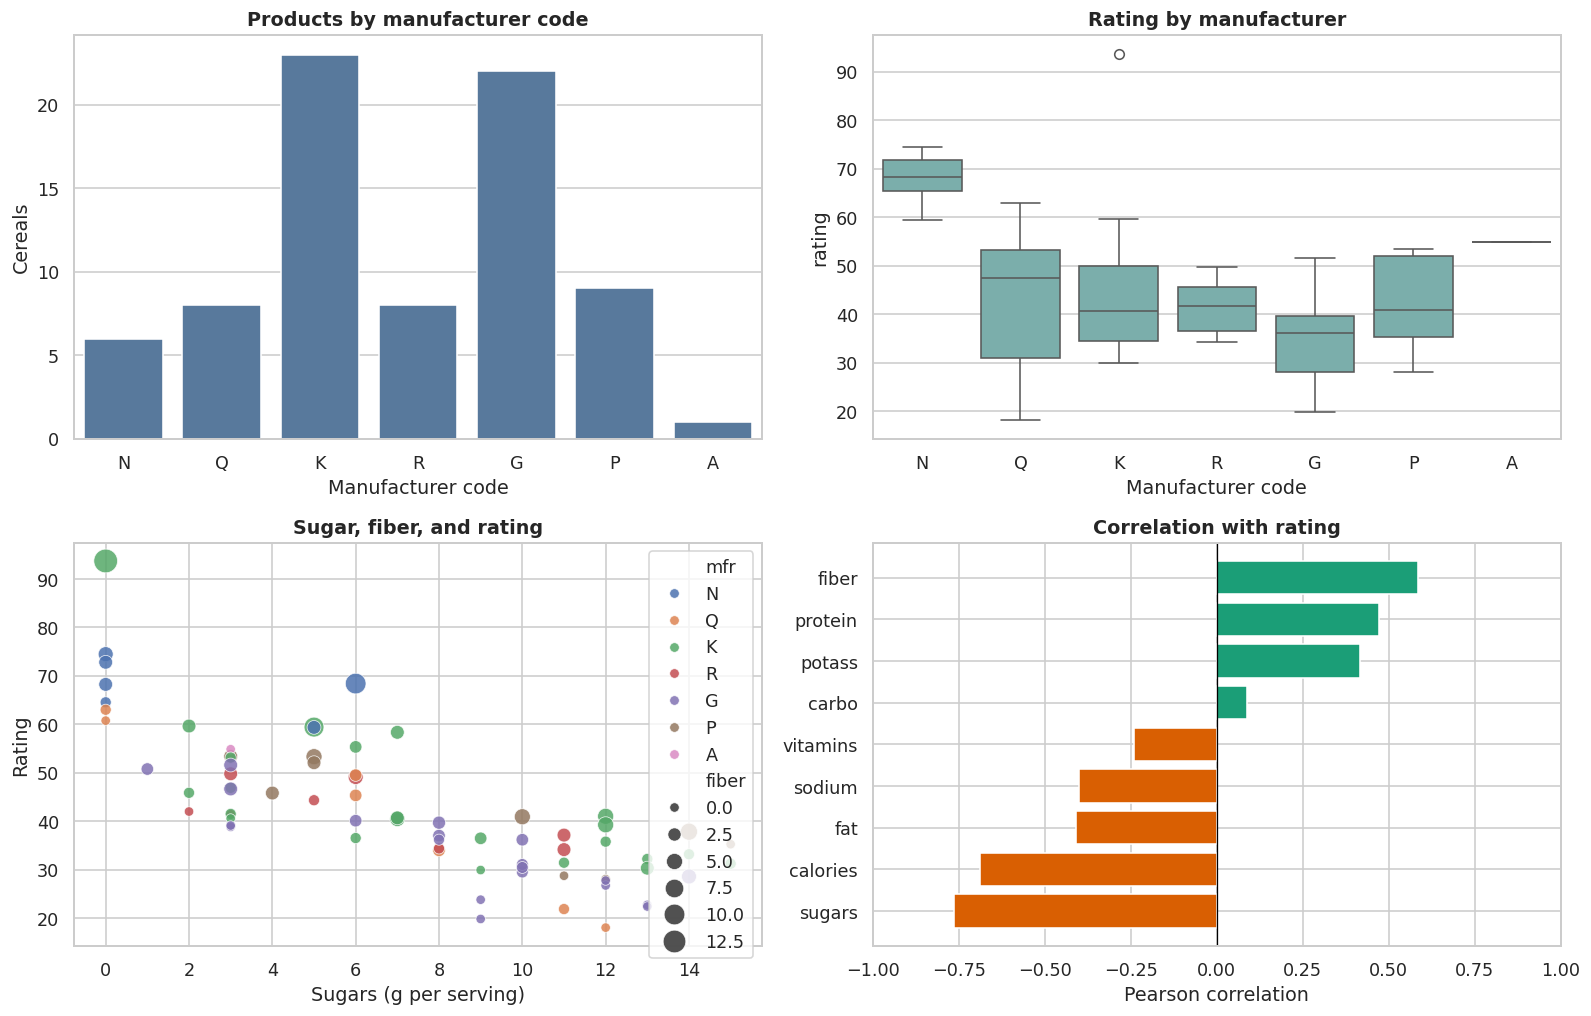

,correlation_with_rating
sugars,-0.764
calories,-0.689
fat,-0.409
sodium,-0.401
vitamins,-0.241
carbo,0.089
potass,0.416
protein,0.471
fiber,0.584


,Q1,Q3,lower fence,upper fence,outliers
variable,,,,,
calories,100.000,110.000,85.000,125.000,14
sodium,130.000,210.000,10.000,330.000,9
fiber,1.000,3.000,-2.000,6.000,3
rating,33.170,50.830,6.690,77.310,1
sugars,3.000,11.000,-9.000,23.000,0


In [16]:
cereal_numeric = ["calories", "protein", "fat", "sodium", "fiber", "carbo", "sugars", "potass", "vitamins", "rating"]
corr_to_rating = cereals[cereal_numeric].corr()["rating"].drop("rating").sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(data=cereals, x="mfr", color="#4c78a8", ax=axes[0, 0])
axes[0, 0].set_title("Products by manufacturer code")
axes[0, 0].set_xlabel("Manufacturer code")
axes[0, 0].set_ylabel("Cereals")

sns.boxplot(data=cereals, x="mfr", y="rating", color="#72b7b2", ax=axes[0, 1])
axes[0, 1].set_title("Rating by manufacturer")
axes[0, 1].set_xlabel("Manufacturer code")

sns.scatterplot(data=cereals, x="sugars", y="rating", hue="mfr", size="fiber", sizes=(35, 220), alpha=0.85, ax=axes[1, 0])
axes[1, 0].set_title("Sugar, fiber, and rating")
axes[1, 0].set_xlabel("Sugars (g per serving)")
axes[1, 0].set_ylabel("Rating")

colors = ["#d95f02" if value < 0 else "#1b9e77" for value in corr_to_rating]
axes[1, 1].barh(corr_to_rating.index, corr_to_rating.values, color=colors)
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_xlim(-1, 1)
axes[1, 1].set_title("Correlation with rating")
axes[1, 1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

display(corr_to_rating.round(3).to_frame("correlation_with_rating"))
display(iqr_table(cereals, ["calories", "sodium", "fiber", "sugars", "rating"]))


**Observation.** The file contains 77 cereals. Sugar has a strong negative correlation with rating (about −0.76), while fiber has a positive correlation (about 0.58). The highest-rated product is All-Bran with Extra Fiber at 93.7.

**Interpretation.** The rating behaves like a nutrition-oriented score: products with more sugar and calories tend to score lower, while high-fiber products tend to score higher. Manufacturer box plots describe each company’s product mix, but comparisons are unstable for manufacturers represented by only a few products.

**Limitation.** One carbohydrate value, one sugar value, and two potassium values use `-1` as a missing-value code. Rating is calculated from nutritional attributes, so correlations between rating and those same attributes are partly built into the score and do not independently prove health effects.


## 5. Red Wine Quality

This dataset contains physicochemical measurements and an ordered sensory quality score. Exact duplicate rows are reported but retained because the file has no observation identifier: repeated measurements and true duplicate records cannot be distinguished safely.


### Commands used in the Red Wine section

- `.duplicated().sum()` counts exact repeated rows.
- `.groupby("quality").agg(...)` calculates several summaries for each quality score.
- A box plot compares the median, spread, and possible outliers across quality groups.

Repeated rows are reported but not automatically deleted because the file has no observation ID to prove that they are data-entry errors.


In [17]:
wine_raw = load_csv("wine")
wine = wine_raw.copy()

show_basic_eda(wine, "Red wine quality")

quality_summary_table = wine.groupby("quality").agg(
    count=("quality", "size"),
    median_alcohol=("alcohol", "median"),
    median_volatile_acidity=("volatile acidity", "median"),
    median_citric_acid=("citric acid", "median"),
).round(3)
display(quality_summary_table)


,value
rows,1599
columns,12
duplicate rows,240
missing cells,0


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5
1,7.800,0.880,0.000,2.600,0.098,25.000,67.000,0.997,3.200,0.680,9.800,5
2,7.800,0.760,0.040,2.300,0.092,15.000,54.000,0.997,3.260,0.650,9.800,5
3,11.200,0.280,0.560,1.900,0.075,17.000,60.000,0.998,3.160,0.580,9.800,6
4,7.400,0.700,0.000,1.900,0.076,11.000,34.000,0.998,3.510,0.560,9.400,5


,dtype,missing,missing_%,unique
fixed acidity,float64,0,0.000,96
volatile acidity,float64,0,0.000,143
citric acid,float64,0,0.000,80
residual sugar,float64,0,0.000,91
chlorides,float64,0,0.000,153
free sulfur dioxide,float64,0,0.000,60
total sulfur dioxide,float64,0,0.000,144
density,float64,0,0.000,436
pH,float64,0,0.000,89
sulphates,float64,0,0.000,96


,count,mean,std,min,25%,50%,75%,max
fixed acidity,"1,599.000",8.320,1.740,4.600,7.100,7.900,9.200,15.900
volatile acidity,"1,599.000",0.530,0.180,0.120,0.390,0.520,0.640,1.580
citric acid,"1,599.000",0.270,0.190,0.000,0.090,0.260,0.420,1.000
residual sugar,"1,599.000",2.540,1.410,0.900,1.900,2.200,2.600,15.500
chlorides,"1,599.000",0.090,0.050,0.010,0.070,0.080,0.090,0.610
free sulfur dioxide,"1,599.000",15.870,10.460,1.000,7.000,14.000,21.000,72.000
total sulfur dioxide,"1,599.000",46.470,32.900,6.000,22.000,38.000,62.000,289.000
density,"1,599.000",1.000,0.000,0.990,1.000,1.000,1.000,1.000
pH,"1,599.000",3.310,0.150,2.740,3.210,3.310,3.400,4.010
sulphates,"1,599.000",0.660,0.170,0.330,0.550,0.620,0.730,2.000


,count,median_alcohol,median_volatile_acidity,median_citric_acid
quality,,,,
3,10,9.925,0.845,0.035
4,53,10.000,0.670,0.090
5,681,9.700,0.580,0.230
6,638,10.500,0.490,0.260
7,199,11.500,0.370,0.400
8,18,12.150,0.370,0.420


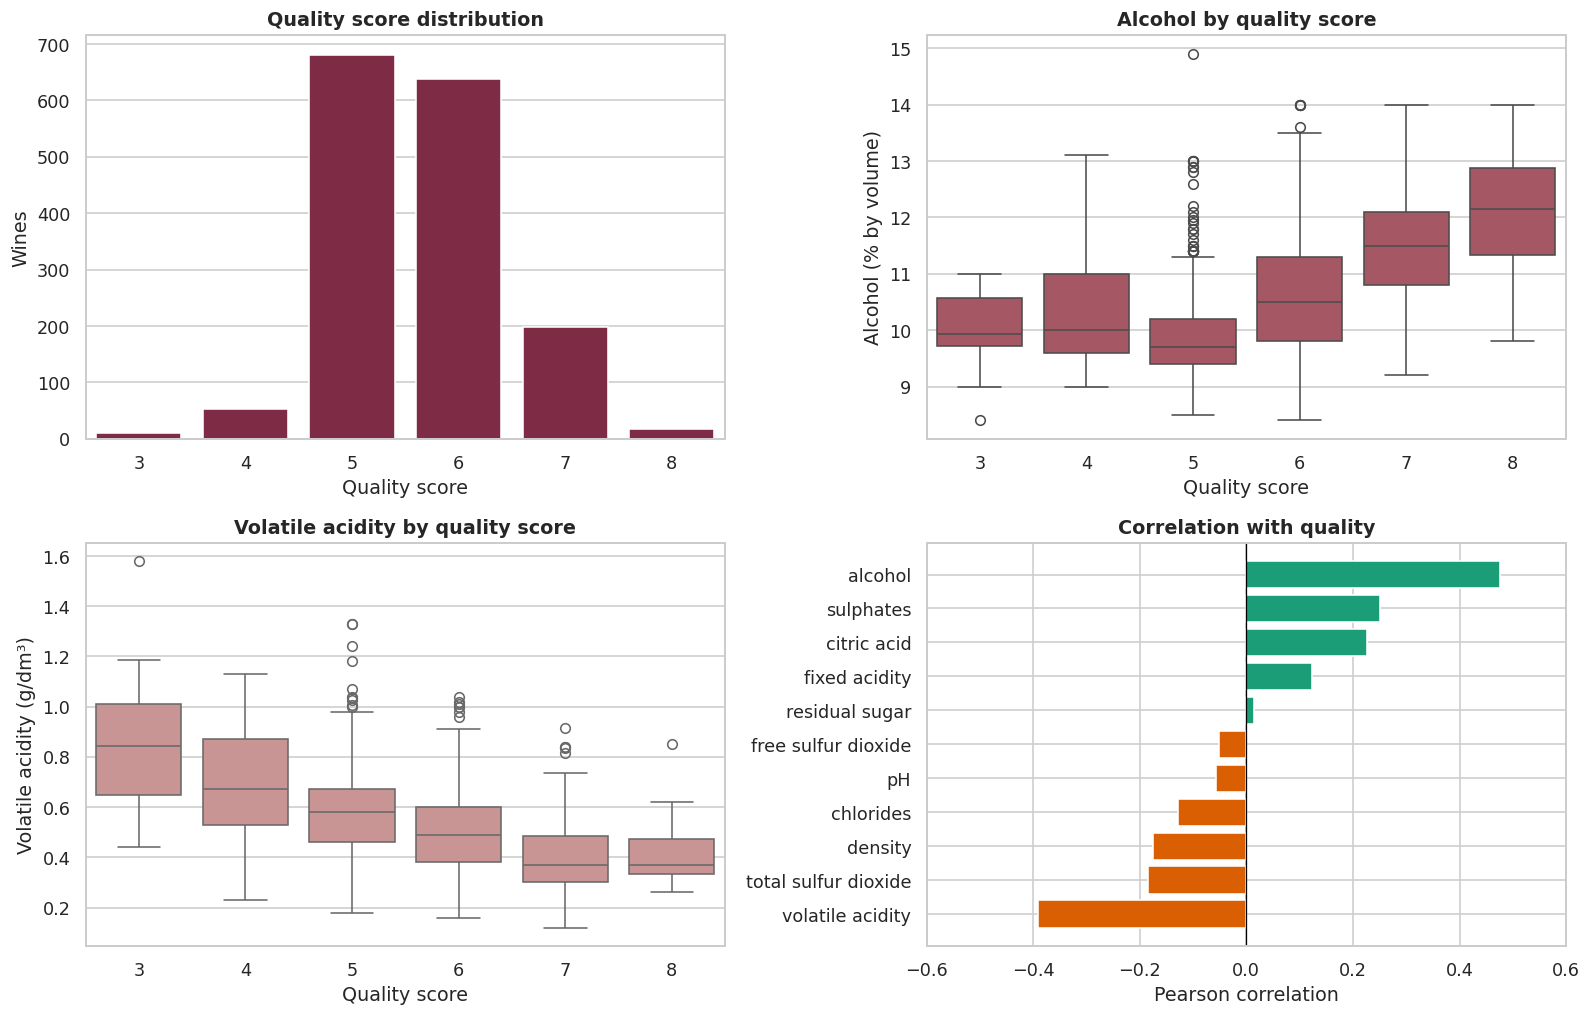

,correlation_with_quality
volatile acidity,-0.391
total sulfur dioxide,-0.185
density,-0.175
chlorides,-0.129
pH,-0.058
free sulfur dioxide,-0.051
residual sugar,0.014
fixed acidity,0.124
citric acid,0.226
sulphates,0.251


,Q1,Q3,lower fence,upper fence,outliers
variable,,,,,
residual sugar,1.900,2.600,0.850,3.650,155
chlorides,0.070,0.090,0.040,0.120,112
sulphates,0.550,0.730,0.280,1.000,59
total sulfur dioxide,22.000,62.000,-38.000,122.000,55
fixed acidity,7.100,9.200,3.950,12.350,49
density,1.000,1.000,0.990,1.000,45
pH,3.210,3.400,2.920,3.680,35
free sulfur dioxide,7.000,21.000,-14.000,42.000,30
volatile acidity,0.390,0.640,0.020,1.020,19


In [18]:
wine_corr = wine.corr(numeric_only=True)["quality"].drop("quality").sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

sns.countplot(data=wine, x="quality", color="#8c1d40", ax=axes[0, 0])
axes[0, 0].set_title("Quality score distribution")
axes[0, 0].set_xlabel("Quality score")
axes[0, 0].set_ylabel("Wines")

sns.boxplot(data=wine, x="quality", y="alcohol", color="#b24a5a", ax=axes[0, 1])
axes[0, 1].set_title("Alcohol by quality score")
axes[0, 1].set_xlabel("Quality score")
axes[0, 1].set_ylabel("Alcohol (% by volume)")

sns.boxplot(data=wine, x="quality", y="volatile acidity", color="#d28b8b", ax=axes[1, 0])
axes[1, 0].set_title("Volatile acidity by quality score")
axes[1, 0].set_xlabel("Quality score")
axes[1, 0].set_ylabel("Volatile acidity (g/dm³)")

colors = ["#d95f02" if value < 0 else "#1b9e77" for value in wine_corr]
axes[1, 1].barh(wine_corr.index, wine_corr.values, color=colors)
axes[1, 1].axvline(0, color="black", linewidth=0.8)
axes[1, 1].set_xlim(-0.6, 0.6)
axes[1, 1].set_title("Correlation with quality")
axes[1, 1].set_xlabel("Pearson correlation")

plt.tight_layout()
plt.show()

display(wine_corr.round(3).to_frame("correlation_with_quality"))
wine_features = [column for column in wine.columns if column != "quality"]
display(iqr_table(wine, wine_features))


**Observation.** The file contains 1,599 measurements and no missing cells, but 240 rows are exact duplicates. Quality ranges from 3 to 8, and 82.5% of observations have quality 5 or 6. Alcohol has the strongest positive linear association with quality (about 0.48), while volatile acidity has the strongest negative association (about −0.39).

**Interpretation.** Higher-scoring wines tend to contain more alcohol and less volatile acidity, but the box plots overlap substantially. No single chemical measurement separates quality groups cleanly, suggesting that quality reflects several measurements and sensory judgment.

**Limitation.** Quality is an ordered, narrow, and imbalanced score, so Pearson correlation is only a simple summary. Duplicate rows may be repeated measurements or duplicates in the data; without an identifier, automatically deleting them could remove valid observations.


## Cross-dataset summary

The following table checks the final cleaned analysis objects. It makes the data-quality differences visible in one place.


In [19]:
final_summary = pd.DataFrame(
    [
        {
            "dataset": "Penguins",
            "rows": len(penguins),
            "columns": penguins.shape[1],
            "missing_cells": int(penguins.isna().sum().sum()),
            "duplicate_rows": int(penguins.duplicated().sum()),
            "main_pattern": "Species strongly separates body size and bill shape",
        },
        {
            "dataset": "Titanic",
            "rows": len(titanic_raw),
            "columns": titanic_raw.shape[1],
            "missing_cells": int(titanic_raw.isna().sum().sum()),
            "duplicate_rows": int(titanic_raw.duplicated().sum()),
            "main_pattern": "Survival differs strongly by sex and passenger class",
        },
        {
            "dataset": "Avocado",
            "rows": len(avocado),
            "columns": avocado.drop(columns="month").shape[1],
            "missing_cells": int(avocado.drop(columns="month").isna().sum().sum()),
            "duplicate_rows": int(avocado.drop(columns="month").duplicated().sum()),
            "main_pattern": "Organic prices are higher and both types vary over time",
        },
        {
            "dataset": "Cereals",
            "rows": len(cereals),
            "columns": cereals.shape[1],
            "missing_cells": int(cereals.isna().sum().sum()),
            "duplicate_rows": int(cereals.duplicated().sum()),
            "main_pattern": "Rating falls with sugar and rises with fiber",
        },
        {
            "dataset": "Red wine",
            "rows": len(wine),
            "columns": wine.shape[1],
            "missing_cells": int(wine.isna().sum().sum()),
            "duplicate_rows": int(wine.duplicated().sum()),
            "main_pattern": "Quality rises with alcohol and falls with volatile acidity",
        },
    ]
).set_index("dataset")

display(final_summary)


,rows,columns,missing_cells,duplicate_rows,main_pattern
dataset,,,,,
Penguins,344,7,19,0,Species strongly separates body size and bill ...
Titanic,891,12,866,0,Survival differs strongly by sex and passenger...
Avocado,18249,13,0,0,Organic prices are higher and both types vary ...
Cereals,77,16,4,0,Rating falls with sugar and rises with fiber
Red wine,1599,12,0,240,Quality rises with alcohol and falls with vola...


## Overall conclusion

These datasets require different EDA choices. Grouped box plots and scatter plots are useful for Penguins, survival-rate comparisons for Titanic, time-series lines for Avocado, nutrition correlations for Cereals, and ordered quality comparisons for Red Wine. Outliers are possible observations to investigate, not automatic errors to delete.

The most important lesson is that EDA combines numerical summaries, visual patterns, and domain-aware interpretation. The plots generate hypotheses; they do not establish causal explanations.

## Kaggle sources

- [Palmer Archipelago Penguins](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data)
- [Titanic](https://www.kaggle.com/competitions/titanic/data)
- [Avocado Prices](https://www.kaggle.com/datasets/neuromusic/avocado-prices)
- [80 Cereals](https://www.kaggle.com/datasets/crawford/80-cereals)
- [Red Wine Quality](https://www.kaggle.com/datasets/uciml/red-wine-quality-cortez-et-al-2009)


## Submission checklist

Before submitting:

- Run **Runtime → Restart session and run all** in Colab.
- Confirm every code cell finishes without a red error.
- Confirm all five dataset sections show tables and charts.
- Read the written observations and rewrite any sentence you want to express in your own voice.
- Save the executed notebook so the charts and outputs remain visible.
- Upload `applied_analytics_01_complete.ipynb` to the root of your GitHub repository.
- Submit the GitHub notebook link required by your course platform.
